<p align="center">
<a href="https://colab.research.google.com/github/md-ryhan-uddin/ai-lab-experiments/blob/main/experiment_08.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<a href="https://kaggle.com/kernels/welcome?src=https://github.com/md-ryhan-uddin/ai-lab-experiments/blob/main/experiment_08.ipynb">
    <img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Open In Kaggle" height="20"/>
</a>
</p>

## **Experiment 08:** Image Classification using Convolutional Neural Networks (CNNs) and Transfer Learning

**Course:** ICE 4111: Artificial Intelligence Lab  
**Program:** Bachelor of Science in Information and Communication Engineering (BSc in ICE)  
**Instructor:** Md. Ryhan Uddin

**Student Name:** ______________________________  
**Student ID:** ______________________________  
**Section/Batch:** ______________________________  
**Date of Submission:** ______________________________  


### **Quick Overview**

In this lab you will build a compact **Convolutional Neural Network (CNN)** from scratch and train it on the Digits dataset, then repeat the classification task using **transfer learning** with a frozen, pretrained **MobileNetV2** feature extractor. You will compare both approaches using learning curves and test accuracy, and visually inspect correct and misclassified predictions from the better-performing model.

### **Learning Objectives**

After completing this experiment, students will be able to:

- Build and train a small CNN with convolution and pooling layers for image classification.
- Apply transfer learning using a pretrained image model as a frozen feature extractor.
- Prepare image data appropriately for each approach (channel format, resizing, RGB conversion).
- Compare training curves and test accuracy between a from-scratch CNN and a transfer-learning model.
- Visualize predictions on sample images, including misclassified cases.


## **Theory**

### Introduction

Convolutional neural networks are designed for image data because they use local receptive fields and parameter sharing. Convolution layers learn edge, texture, and shape detectors; pooling layers reduce spatial resolution while retaining the strongest activations; and dense layers map the resulting learned features to class probabilities. **Transfer learning** reuses a model pretrained on a large dataset (such as ImageNet) and adapts it to a smaller target task, which is especially useful when the target dataset is too small to train a deep network from scratch.

### Mathematical Background

For an input image $X$ and kernel $K$ of size $k \times k$, a convolutional feature map is computed by sliding the kernel across the image and taking dot products with local patches:

$$S(i, j) = \sum_{m}\sum_{n} X(i+m,\, j+n)\, K(m, n)$$

followed by a non-linear activation such as ReLU. Pooling (e.g. max pooling) reduces spatial resolution while preserving the most important activations, which controls parameter count and adds a degree of translation invariance.

In transfer learning, a pretrained base model learns a general-purpose feature function $\phi(X)$ on a large source dataset. The base is frozen (its weights are not updated), and only a new classifier head — typically global average pooling followed by one or more dense layers — is trained on the target dataset:

$$\hat{y} = \text{softmax}\big(W_2\, \phi(X) + b_2\big)$$

### Important Concepts

A CNN training pipeline is: prepare images, normalize pixel values, build convolution and pooling blocks, train with early stopping, and evaluate on held-out data. For transfer learning, the same images are resized to match the pretrained model's expected input size, converted to three channels if necessary, and passed through a **frozen** feature extractor so its ImageNet-learned filters are preserved. Only the newly added classifier head is trained. This two-stage idea can be extended with **fine-tuning**, where a few of the base model's top layers are later unfrozen and trained at a very low learning rate to adapt the pretrained features more closely to the target domain.

### Advantages and Applications

**Advantages**

- CNNs are excellent for images because they exploit spatial structure and local patterns with far fewer parameters than a fully dense network.
- Transfer learning often improves accuracy and reduces training time when the target dataset is small.

**Disadvantages**

- CNNs can still overfit on limited data if not regularized.
- Transfer learning depends on how relevant the pretrained source domain (e.g. natural photographs) is to the target domain (e.g. small grayscale digit images).

**Applications**

These methods are widely used in medical imaging, optical character recognition (OCR), object recognition, remote sensing, and industrial defect detection.

```mermaid
flowchart LR
    A[Image Input] --> B[Conv + ReLU]
    B --> C[Pooling]
    C --> D[Flatten / Global Pooling]
    D --> E[Dense Classifier]
    E --> F[Softmax Output]
    G[Pretrained Base: MobileNetV2, Frozen] --> D
```


## **Required Software and Libraries**

Install or prepare the following before starting the lab:

- Python 3.12 or later
- Jupyter Notebook, JupyterLab, VS Code, or Google Colab
- NumPy
- Matplotlib
- TensorFlow 2.x / Keras
- Scikit-learn
- An active internet connection, required the first time `MobileNetV2` downloads its pretrained ImageNet weights (Colab has this by default)

### Starter Check

Run the first code cell (library imports and setup). If it prints `Setup complete. You can start the experiment.`, your environment is ready.

## **Dataset Description**

This experiment uses the **Digits dataset** from Scikit-learn because it is available locally and small enough to support both a from-scratch CNN and a transfer learning demonstration without external dataset downloads.

- **Features:** 8x8 grayscale images of handwritten digits.
- **Target labels:** digits 0 through 9 (10 classes).
- **Source:** `sklearn.datasets.load_digits`.
- **Reason for selection:** self-contained dataset that trains quickly on CPU. The grayscale images are kept at 8x8 for the CNN, and resized to 96x96 RGB for the MobileNetV2-based transfer learning model.

## **Experimental Procedure**

Follow the steps below in order:

1. Load and normalize the Digits dataset, and inspect a few sample images.
2. Split the data into training, validation, and test sets.
3. Build and train a small CNN on the original 8x8 grayscale images.
4. Convert the images to RGB and resize them to 96x96 for transfer learning.
5. Load a frozen, pretrained MobileNetV2 base and train only a new classifier head on top of it.
6. Compare the two models using accuracy, learning curves, and a confusion matrix.
7. Visualize sample correct and misclassified predictions from the stronger model.

### Student Checkpoint

Before moving to the discussion section, make sure you can answer:

- Why must the images be converted to RGB and resized to 96x96 before being passed to MobileNetV2, but not before being passed to the custom CNN?
- Why is `base_model.trainable = False` set for the transfer learning model, and what would change if it were `True`?
- Which of the two models achieved higher test accuracy on this dataset, and does that match your expectation given how small and low-resolution the Digits images are compared to ImageNet photographs?


## **Source Code**

Run the following cells one by one. Read the output after each cell and add comments in your own words where instructed by your teacher.

**Tip:** Do not only run the notebook. Try adding a `Dropout` layer to the CNN, or unfreezing the last few layers of MobileNetV2, and observe what changes.

**Note:** The transfer learning cells download the pretrained MobileNetV2 weights the first time they run, so they require an active internet connection (Colab provides this automatically).

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # suppress verbose TensorFlow startup logs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
tf.get_logger().setLevel("ERROR")

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

tf.keras.utils.set_random_seed(42)
np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

print("Setup complete. You can start the experiment.")

Setup complete. You can start the experiment.


In [2]:
# Load and Normalize the Digits Dataset

digits = load_digits()
X = digits.images.astype("float32") / 16.0
y = digits.target

print("Shape:", X.shape)
print("Class counts:\n", np.bincount(y))
print("Pixel value range after scaling: [{:.2f}, {:.2f}]".format(X.min(), X.max()))

Shape: (1797, 8, 8)
Class counts:
 [178 182 177 183 181 182 181 179 174 180]
Pixel value range after scaling: [0.00, 1.00]


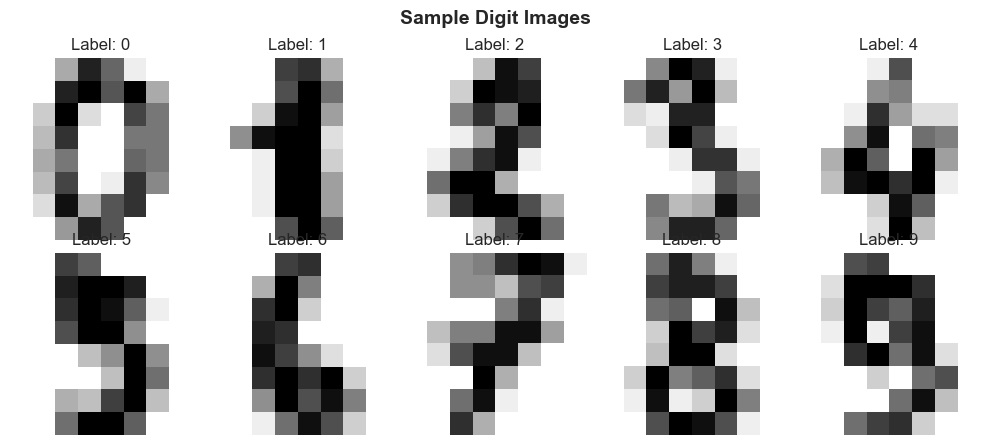

In [3]:
# Visualize Sample Digit Images

fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(X[i], cmap="gray_r")
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")

plt.suptitle("Sample Digit Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [4]:
# Train / Validation / Test Split

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full,
)

# Add the channel dimension required by Conv2D: (samples, height, width, channels)
X_train_cnn = X_train[..., np.newaxis]
X_val_cnn = X_val[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

print("Train shape     :", X_train_cnn.shape)
print("Validation shape:", X_val_cnn.shape)
print("Test shape      :", X_test_cnn.shape)

Train shape     : (1149, 8, 8, 1)
Validation shape: (288, 8, 8, 1)
Test shape      : (360, 8, 8, 1)


In [5]:
# Build the CNN

cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(8, 8, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 8, 8, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,914 (140.29 KB)

 Trainable params: 35,914 (140.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the CNN with Early Stopping

cnn_history = cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=30,
    batch_size=32,
    verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
)

print(f"CNN training completed after {len(cnn_history.history['loss'])} epochs.")

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.3005 - loss: 2.2260 - val_accuracy: 0.6389 - val_loss: 1.7952
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7515 - loss: 1.5190 - val_accuracy: 0.9201 - val_loss: 0.6751
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9033 - loss: 0.5560 - val_accuracy: 0.9583 - val_loss: 0.2970
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9438 - loss: 0.2639 - val_accuracy: 0.9722 - val_loss: 0.1887
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9599 - loss: 0.1655 - val_accuracy: 0.9757 - val_loss: 0.1416
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9806 - loss: 0.1155 - val_accuracy: 0.9792 - val_loss: 0.1164
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9884 - loss: 0.0883 - val_accuracy: 0.9757 - val_loss: 0.1041
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9894 - loss: 0.0707 - val_accuracy: 0.9757 - v

In [7]:
# Evaluate the CNN on the Test Set

cnn_test_prob = cnn_model.predict(X_test_cnn, verbose=0)
cnn_test_pred = np.argmax(cnn_test_prob, axis=1)

cnn_accuracy = accuracy_score(y_test, cnn_test_pred)
print(f"CNN Test Accuracy : {cnn_accuracy:.4f}")
print(classification_report(y_test, cnn_test_pred, target_names=[str(i) for i in range(10)]))

CNN Test Accuracy : 0.9750
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.90      1.00      0.95        36
           2       1.00      1.00      1.00        35
           3       1.00      0.97      0.99        37
           4       0.97      0.97      0.97        36
           5       0.97      1.00      0.99        37
           6       0.97      0.97      0.97        36
           7       0.97      1.00      0.99        36
           8       0.97      0.86      0.91        35
           9       1.00      1.00      1.00        36

    accuracy                           0.97       360
   macro avg       0.98      0.97      0.97       360
weighted avg       0.98      0.97      0.97       360



In [8]:
# Prepare Images for Transfer Learning (RGB, Resized to 96x96)

def resize_for_transfer(images):
    images_rgb = np.repeat(images[..., np.newaxis], 3, axis=-1)   # grayscale -> 3 channels
    images_resized = tf.image.resize(images_rgb, (96, 96)).numpy()  # match MobileNetV2 input size
    return images_resized

X_train_tl = resize_for_transfer(X_train)
X_val_tl = resize_for_transfer(X_val)
X_test_tl = resize_for_transfer(X_test)

print("Transfer learning input shape:", X_train_tl.shape)

Transfer learning input shape: (1149, 96, 96, 3)


In [9]:
# Build the Transfer Learning Model (Frozen MobileNetV2 + New Classifier Head)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False  # freeze the pretrained feature extractor

transfer_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(96, 96, 3)),
    tf.keras.layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

transfer_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,618 (8.93 MB)

 Trainable params: 82,634 (322.79 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
# Train Only the Classifier Head (Early Stopping)

transfer_history = transfer_model.fit(
    X_train_tl, y_train,
    validation_data=(X_val_tl, y_val),
    epochs=10,
    batch_size=32,
    verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
)

print(f"Transfer learning training completed after {len(transfer_history.history['loss'])} epochs.")

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 26s 316ms/step - accuracy: 0.1000 - loss: 2.3938 - val_accuracy: 0.0972 - val_loss: 2.3093
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 203ms/step - accuracy: 0.1099 - loss: 2.3349 - val_accuracy: 0.1076 - val_loss: 2.3157
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 203ms/step - accuracy: 0.1054 - loss: 2.3189 - val_accuracy: 0.1042 - val_loss: 2.3053
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 218ms/step - accuracy: 0.1087 - loss: 2.3069 - val_accuracy: 0.1042 - val_loss: 2.3111
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 201ms/step - accuracy: 0.1017 - loss: 2.3098 - val_accuracy: 0.1007 - val_loss: 2.2990
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 217ms/step - accuracy: 0.1032 - loss: 2.3045 - val_accuracy: 0.1007 - val_loss: 2.2988
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 199ms/step - accuracy: 0.1025 - loss: 2.3013 - val_accuracy: 0.1007 - val_loss: 2.2984
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 225ms/step - accuracy: 0.1094 - loss: 2.3022 - val_accuracy

In [11]:
# Evaluate the Transfer Learning Model on the Test Set

transfer_test_prob = transfer_model.predict(X_test_tl, verbose=0)
transfer_test_pred = np.argmax(transfer_test_prob, axis=1)

transfer_accuracy = accuracy_score(y_test, transfer_test_pred)
print(f"Transfer Learning Test Accuracy : {transfer_accuracy:.4f}")
print(classification_report(y_test, transfer_test_pred, target_names=[str(i) for i in range(10)]))

Transfer Learning Test Accuracy : 0.1000
              precision    recall  f1-score   support

           0       0.10      1.00      0.18        36
           1       0.00      0.00      0.00        36
           2       0.00      0.00      0.00        35
           3       0.00      0.00      0.00        37
           4       0.00      0.00      0.00        36
           5       0.00      0.00      0.00        37
           6       0.00      0.00      0.00        36
           7       0.00      0.00      0.00        36
           8       0.00      0.00      0.00        35
           9       0.00      0.00      0.00        36

    accuracy                           0.10       360
   macro avg       0.01      0.10      0.02       360
weighted avg       0.01      0.10      0.02       360



c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [12]:
# Compare CNN vs Transfer Learning

comparison_df = pd.DataFrame([
    ["CNN (from scratch)", cnn_accuracy, len(cnn_history.history["loss"])],
    ["Transfer Learning (MobileNetV2)", transfer_accuracy, len(transfer_history.history["loss"])],
], columns=["Model", "Test Accuracy", "Epochs Trained"]).round(4)

comparison_df

,Model,Test Accuracy,Epochs Trained
0,CNN (from scratch),0.975,21
1,Transfer Learning (MobileNetV2),0.100,10


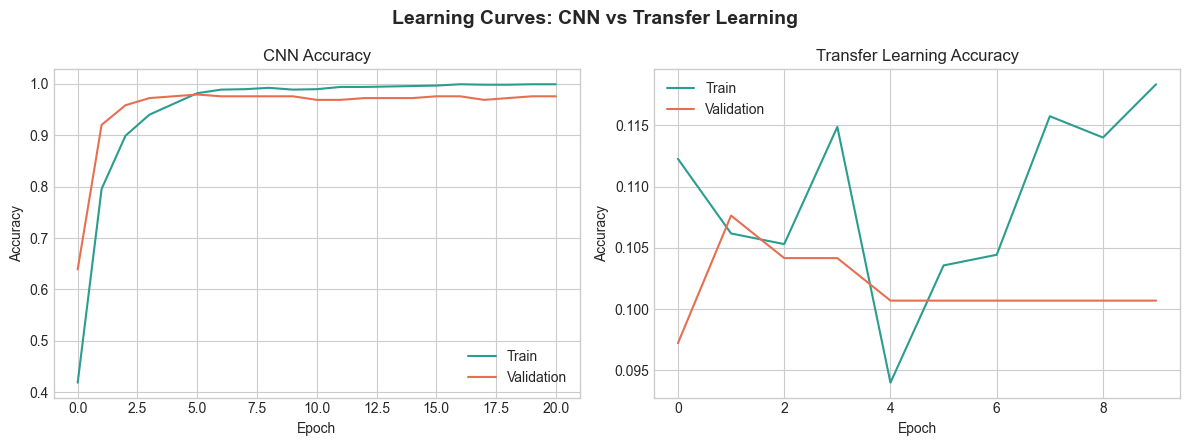

In [13]:
# Training vs Validation Accuracy: CNN vs Transfer Learning

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(cnn_history.history["accuracy"], label="Train", color="#2a9d8f")
axes[0].plot(cnn_history.history["val_accuracy"], label="Validation", color="#e76f51")
axes[0].set_title("CNN Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(transfer_history.history["accuracy"], label="Train", color="#2a9d8f")
axes[1].plot(transfer_history.history["val_accuracy"], label="Validation", color="#e76f51")
axes[1].set_title("Transfer Learning Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.suptitle("Learning Curves: CNN vs Transfer Learning", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

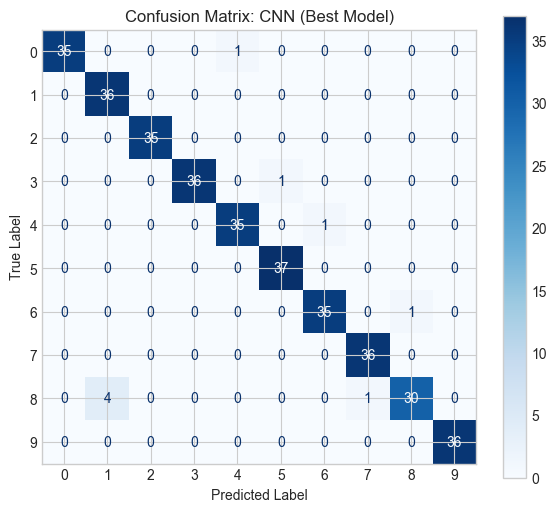

In [14]:
# Confusion Matrix for the Stronger Model

if transfer_accuracy >= cnn_accuracy:
    best_name, best_pred = "Transfer Learning", transfer_test_pred
else:
    best_name, best_pred = "CNN", cnn_test_pred

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[str(i) for i in range(10)])

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap="Blues", ax=ax, colorbar=True, values_format="d")

plt.title(f"Confusion Matrix: {best_name} (Best Model)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Best Model             : CNN
Correctly classified   : 351 / 360
Misclassified           : 9 / 360


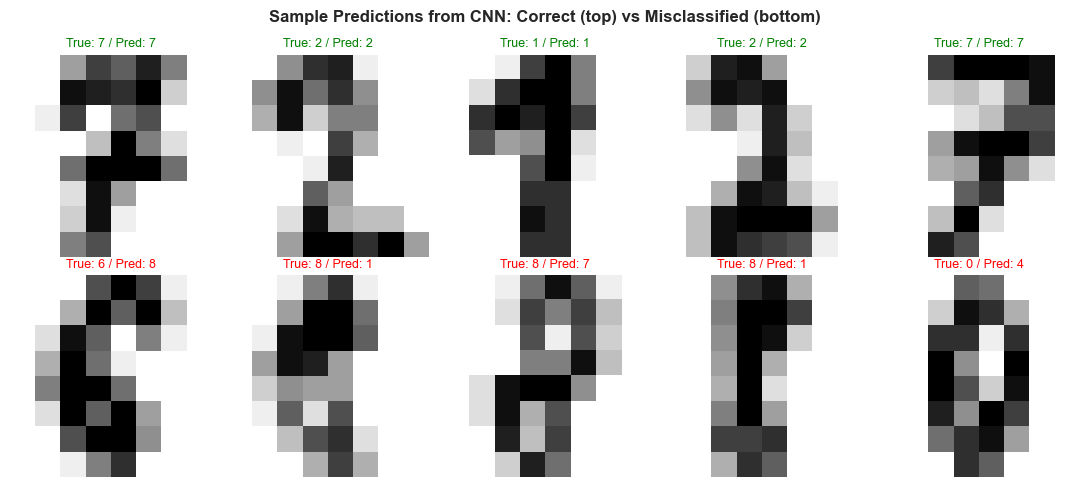

In [15]:
# Visualize Correct and Misclassified Predictions from the Best Model

misclassified = np.where(best_pred != y_test)[0]
correct = np.where(best_pred == y_test)[0]

print(f"Best Model             : {best_name}")
print(f"Correctly classified   : {len(correct)} / {len(y_test)}")
print(f"Misclassified           : {len(misclassified)} / {len(y_test)}")

sample_correct = np.random.choice(correct, size=5, replace=False)
sample_wrong = misclassified[:5] if len(misclassified) >= 5 else misclassified

fig, axes = plt.subplots(2, 5, figsize=(11, 5))

for ax, idx in zip(axes[0], sample_correct):
    ax.imshow(X_test[idx], cmap="gray_r")
    ax.set_title(f"True: {y_test[idx]} / Pred: {best_pred[idx]}", fontsize=9, color="green")
    ax.axis("off")

for ax, idx in zip(axes[1], sample_wrong):
    ax.imshow(X_test[idx], cmap="gray_r")
    ax.set_title(f"True: {y_test[idx]} / Pred: {best_pred[idx]}", fontsize=9, color="red")
    ax.axis("off")

for ax in axes[1][len(sample_wrong):]:
    ax.axis("off")

plt.suptitle(f"Sample Predictions from {best_name}: Correct (top) vs Misclassified (bottom)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## **Expected Output**

After running all cells, the notebook should display:

- Dataset shape, class counts, and a grid of sample digit images.
- Train/validation/test split shapes.
- The CNN summary, its training-completion epoch, test accuracy, and classification report.
- The transfer learning model summary (with the frozen MobileNetV2 base), its training-completion epoch, test accuracy, and classification report.
- A comparison table of both models' test accuracy and training length.
- Side-by-side learning curves for the CNN and the transfer learning model.
- A confusion matrix for whichever model performed best.
- A grid of correctly classified and misclassified sample digit images from the best model.

You should include the important outputs in your lab report and briefly explain what each output means.

## **Performance Evaluation**

For image classification, the key metrics are test accuracy and the shape of the learning curves. In transfer learning, a stronger result is expected when the pretrained feature extractor captures visual patterns that are actually useful for the target dataset; on very small, low-resolution, grayscale images like the Digits dataset, a compact from-scratch CNN can sometimes match or beat a frozen ImageNet-pretrained model, since ImageNet's natural-photograph features do not transfer perfectly to 8x8 handwritten digits. Compare both models' accuracy, the number of epochs each needed to converge, and their confusion matrices to judge which approach really suits this dataset.

## **Discussion**

The CNN is compact and trains quickly on the small Digits dataset, learning convolutional filters directly from the 8x8 grayscale images. Transfer learning can improve representation power on more complex, natural images, but here the pretrained MobileNetV2 model is much larger than the data really requires, and its ImageNet features were learned from color photographs rather than small handwritten digits. This experiment illustrates the transfer learning *workflow* rather than guaranteeing an accuracy improvement — in practice, transfer learning helps most when the target domain resembles the pretrained source domain and when the target dataset is too small or too complex to train a good CNN from scratch.

## **Viva Questions**

1. **Q:** Why are CNNs effective for images?  
   **A:** They exploit local spatial patterns and share weights across the image, which drastically reduces the number of parameters compared to a fully dense network.

2. **Q:** What is pooling used for?  
   **A:** To reduce spatial size while retaining the most important activations, which lowers computation and adds some translation invariance.

3. **Q:** What is transfer learning?  
   **A:** Reusing a model pretrained on a large source dataset and adapting it to a new, usually smaller, target task.

4. **Q:** Why freeze the base model's layers in transfer learning?  
   **A:** To preserve the useful features it already learned and to reduce training cost, since only the new classifier head needs to be trained.

5. **Q:** Why do we resize and convert the images to RGB for MobileNetV2, but not for the custom CNN?  
   **A:** Because MobileNetV2 was pretrained on 3-channel ImageNet images at a fixed input size, while the custom CNN is built from scratch and can accept any input shape we define, including single-channel 8x8 images.

6. **Q:** What does early stopping do?  
   **A:** It stops training when validation performance stops improving for a set number of epochs, and restores the best-performing weights.

7. **Q:** What is the role of ReLU in the convolutional layers?  
   **A:** It introduces non-linearity and helps gradients flow well during backpropagation.

8. **Q:** Why is the Digits dataset useful for this experiment despite being very different from ImageNet?  
   **A:** It is small, local, and trains quickly, letting the workflow for both approaches be demonstrated cheaply on CPU — even though it also nicely illustrates the limits of transfer learning across mismatched domains.

9. **Q:** What is the key structural difference between a CNN and a plain dense network when applied to images?  
   **A:** A CNN preserves spatial structure and applies shared local filters, while a dense network flattens the image and treats every pixel independently.

10. **Q:** What would you change to potentially improve the transfer learning model's accuracy on this dataset?  
    **A:** Unfreeze and fine-tune the last few layers of MobileNetV2 at a low learning rate, or use a larger/more relevant pretrained base, or increase the resized image resolution.

## **Exercises**

Complete the following tasks after running the notebook:

1. Add a `Dropout` layer to the CNN and compare validation accuracy and the train/validation gap.
2. Unfreeze the last few layers of MobileNetV2 (`base_model.trainable = True` with only the top layers trainable) and fine-tune the model at a low learning rate.
3. Try a different pretrained base such as `EfficientNetB0` or `MobileNetV3Small` and compare the results.
4. Increase the resized image size for transfer learning (e.g. 128x128) and observe the change in training time and accuracy.
5. Repeat the comparison on a different Scikit-learn image-like dataset, if available, or on a subset of MNIST if you have internet access to load it.

## **Lab Report Submission Checklist**

Before submitting, confirm that your report includes:

- Completed cover information.
- Objective and theory summary in your own words.
- All important code outputs, including both classification reports and the comparison table.
- The learning curves, confusion matrix, and sample prediction images.
- Short discussion of which model performed best and why, referencing the domain mismatch between ImageNet and the Digits dataset.
- Answers to assigned viva questions.
- Completed exercises.

**Reminder:** A good lab report should not only show screenshots. It should explain what the outputs mean.
